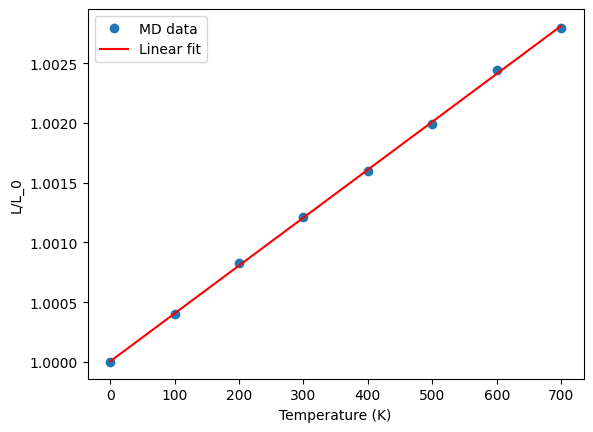

Thermal expansion coefficient = 4.012523e-06


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_and_process_data(filepath):
    data = pd.read_csv(filepath, sep=r'\s+', header=None)
    normalized_data = data.iloc[:, 1] / data.iloc[0, 1]
    return data.iloc[:, 0], normalized_data

def fit_polynomial(x_data, y_data):
    coefficients = np.polyfit(x_data, y_data, 1)
    return coefficients

def plot_data(x_data, y_data, fit_x, fit_y, figure_number, x_label, y_label, legend_labels):
    plt.figure(figure_number)
    plt.plot(x_data, y_data, 'o', label=legend_labels[0])
    plt.plot(fit_x, fit_y, 'r-', label=legend_labels[1])
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend(loc=2)
    plt.show()

def main():
    temperature, length_ratio = load_and_process_data('out_thermalexpansioncoeff.data')
    temp_range = np.arange(0, 701)
    coefficients = fit_polynomial(temperature, length_ratio)
    fitted_values = np.polyval(coefficients, temp_range)
    
    plot_data(temperature, length_ratio, temp_range, fitted_values, 1,
              'Temperature (K)', 'L/L_0', ['MD data', 'Linear fit'])
    
    print(f"Thermal expansion coefficient = {coefficients[0]:.6e}")

if __name__ == "__main__":
    main()
